In [ ]:
import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
print("=" * 60)
print(" Import des bibliothèques et configuration terminés ")

 Import des bibliothèques et configuration terminés 


In [16]:

print("=" * 60)
print("ÉTAPE 1 : Téléchargement du dataset via KaggleHub")
print("=" * 60)

path = kagglehub.dataset_download("mohammedtawfikmusaed/asthma-detection-dataset-version-2")
print(f"Dataset téléchargé dans : {path}")
print("\n- Structure du dataset :")
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}📂 {os.path.basename(root)}/")
    if level < 3:  # Limiter l'affichage
        for f in files[:5]:
            print(f"{indent}  - {f}")
        if len(files) > 5:
            print(f"{indent}  ... et {len(files)-5} autres fichiers")

ÉTAPE 1 : Téléchargement du dataset via KaggleHub
Dataset téléchargé dans : /Users/eliekanga/.cache/kagglehub/datasets/mohammedtawfikmusaed/asthma-detection-dataset-version-2/versions/1

- Structure du dataset :
📂 1/
  - Des.txt
  - .DS_Store
  📂 Asthma Detection Dataset Version 2/
    - Des.txt
    - .DS_Store
    📂 Asthma Detection Dataset Version 2/
      - .DS_Store
      📂 healthy/
      📂 Bronchial/
      📂 asthma/
      📂 pneumonia/
      📂 copd/


In [17]:
# ============================================================
# 2. CONSTRUCTION DU CATALOGUE DE FICHIERS
# ============================================================

print("\n" + "=" * 60)
print("ÉTAPE 2 : Construction du catalogue de fichiers audio")
print("=" * 60)

# Mapper les noms de dossiers possibles vers les classes standardisées
CLASS_MAPPING = {
    'asthma':    'Asthma',
    'asthme':    'Asthma',
    'copd':      'COPD',
    'bpco':      'COPD',
    'bronchial': 'Bronchial',
    'bronchique':'Bronchial',
    'pneumonia': 'Pneumonia',
    'pneumonie': 'Pneumonia',
    'healthy':   'Healthy',
    'sain':      'Healthy',
    'normal':    'Healthy',
}

records = []

for wav_path in Path(path).rglob("*.wav"):
    # Détecter la classe depuis le nom du dossier parent
    folder = wav_path.parent.name.lower().strip()
    label = CLASS_MAPPING.get(folder, folder.capitalize())
    
    records.append({
        'filepath':  str(wav_path),
        'filename':  wav_path.name,
        'label':     label,
        'folder':    folder,
    })

df = pd.DataFrame(records)
print(f"- {len(df)} fichiers audio trouvés")
print(f"- Classes détectées : {df['label'].unique().tolist()}")
print(f"\n{df.head(10)}")



ÉTAPE 2 : Construction du catalogue de fichiers audio
- 1211 fichiers audio trouvés
- Classes détectées : ['Healthy', 'Bronchial', 'Asthma', 'Pneumonia', 'COPD']

                                            filepath           filename  \
0  /Users/eliekanga/.cache/kagglehub/datasets/moh...  P11Healthy30S.wav   
1  /Users/eliekanga/.cache/kagglehub/datasets/moh...  P13Healthy69S.wav   
2  /Users/eliekanga/.cache/kagglehub/datasets/moh...  P24Healthy58S.wav   
3  /Users/eliekanga/.cache/kagglehub/datasets/moh...  P19Healthy62S.wav   
4  /Users/eliekanga/.cache/kagglehub/datasets/moh...  P13Healthy28S.wav   
5  /Users/eliekanga/.cache/kagglehub/datasets/moh...   P6Healthy34S.wav   
6  /Users/eliekanga/.cache/kagglehub/datasets/moh...  P13Healthy53S.wav   
7  /Users/eliekanga/.cache/kagglehub/datasets/moh...  P24Healthy62S.wav   
8  /Users/eliekanga/.cache/kagglehub/datasets/moh...  P25Healthy20S.wav   
9  /Users/eliekanga/.cache/kagglehub/datasets/moh...  P23Healthy14S.wav   

     label

In [18]:
# ============================================================
# 3. EXTRACTION DES MÉTADONNÉES AUDIO
# ============================================================

print("\n" + "=" * 60)
print("ÉTAPE 3 : Extraction des métadonnées audio (peut prendre ~2 min)")
print("=" * 60)

def extract_metadata(filepath):
    """Extrait les propriétés basiques d'un fichier WAV."""
    try:
        y, sr = librosa.load(filepath, sr=None)  # sr=None → sample rate original
        duration   = librosa.get_duration(y=y, sr=sr)
        amplitude  = float(np.max(np.abs(y)))
        rms        = float(np.sqrt(np.mean(y**2)))
        return {
            'sample_rate': sr,
            'duration_s':  round(duration, 3),
            'n_samples':   len(y),
            'amplitude_max': round(amplitude, 4),
            'rms':           round(rms, 6),
            'error':         None
        }
    except Exception as e:
        return {
            'sample_rate': None, 'duration_s': None,
            'n_samples': None, 'amplitude_max': None,
            'rms': None, 'error': str(e)
        }

# Appliquer sur tout le dataset
meta_list = []
for i, row in df.iterrows():
    meta = extract_metadata(row['filepath'])
    meta_list.append(meta)
    if (i + 1) % 100 == 0:
        print(f"  - {i+1}/{len(df)} fichiers traités...")

meta_df = pd.DataFrame(meta_list)
df = pd.concat([df, meta_df], axis=1)

# Fichiers corrompus
n_errors = df['error'].notna().sum()
print(f"\n-  Fichiers avec erreur : {n_errors}")
if n_errors > 0:
    print(df[df['error'].notna()][['filename', 'label', 'error']])

df_clean = df[df['error'].isna()].copy()
print(f"- Fichiers valides : {len(df_clean)}")



ÉTAPE 3 : Extraction des métadonnées audio (peut prendre ~2 min)
  - 100/1211 fichiers traités...
  - 200/1211 fichiers traités...
  - 300/1211 fichiers traités...
  - 400/1211 fichiers traités...
  - 500/1211 fichiers traités...
  - 600/1211 fichiers traités...
  - 700/1211 fichiers traités...
  - 800/1211 fichiers traités...
  - 900/1211 fichiers traités...
  - 1000/1211 fichiers traités...
  - 1100/1211 fichiers traités...
  - 1200/1211 fichiers traités...

-  Fichiers avec erreur : 0
- Fichiers valides : 1211



ÉTAPE 4 : Distribution des classes
           Effectif  Pourcentage
label                           
COPD            401         33.1
Asthma          288         23.8
Pneumonia       285         23.5
Healthy         133         11.0
Bronchial       104          8.6

- Classe majoritaire : COPD (401 samples)
- Classe minoritaire : Bronchial (104 samples)
-  Ratio de déséquilibre : 3.9x


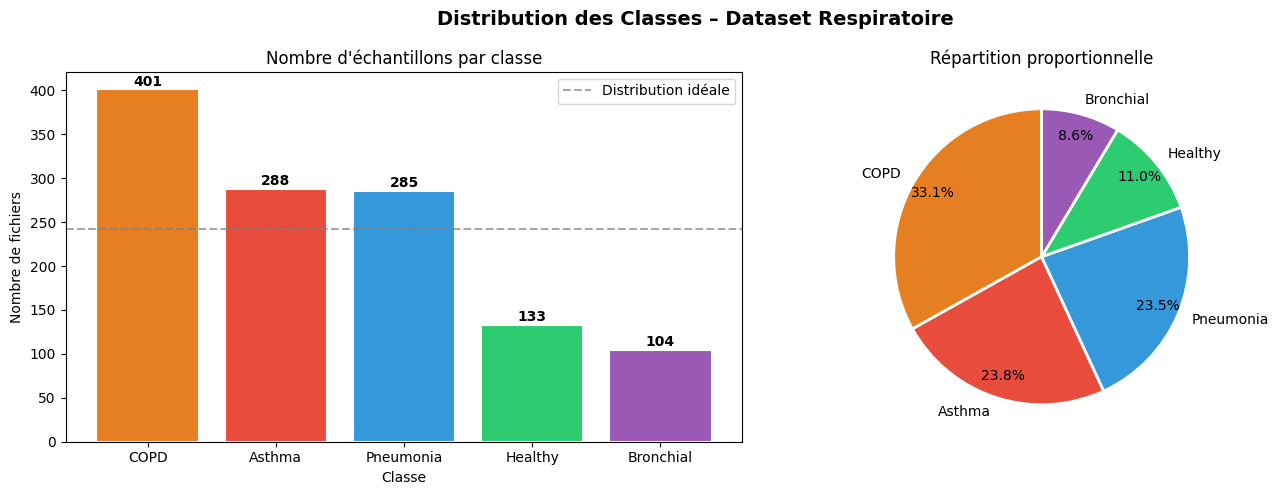

- Graphique sauvegardé : distribution_classes.png


In [19]:
# ============================================================
# 4. ANALYSE DE LA DISTRIBUTION DES CLASSES
# ============================================================

print("\n" + "=" * 60)
print("ÉTAPE 4 : Distribution des classes")
print("=" * 60)

class_counts = df_clean['label'].value_counts()
class_pct    = df_clean['label'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'Effectif':    class_counts,
    'Pourcentage': class_pct.round(1)
})
print(summary)

# Détection du déséquilibre
majority   = class_counts.idxmax()
minority   = class_counts.idxmin()
imb_ratio  = class_counts.max() / class_counts.min()
print(f"\n- Classe majoritaire : {majority} ({class_counts[majority]} samples)")
print(f"- Classe minoritaire : {minority} ({class_counts[minority]} samples)")
print(f"-  Ratio de déséquilibre : {imb_ratio:.1f}x")

# ---------- VISUALISATION ----------
CLASS_COLORS = {
    'Asthma':    '#E74C3C',
    'COPD':      '#E67E22',
    'Bronchial': '#9B59B6',
    'Pneumonia': '#3498DB',
    'Healthy':   '#2ECC71'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution des Classes – Dataset Respiratoire", fontsize=14, fontweight='bold')

# Bar chart
colors = [CLASS_COLORS.get(c, '#95A5A6') for c in class_counts.index]
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title("Nombre d'échantillons par classe")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Nombre de fichiers")
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[0].axhline(y=len(df_clean)/5, color='gray', linestyle='--', alpha=0.7, label='Distribution idéale')
axes[0].legend()

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index,
            colors=colors, autopct='%1.1f%%',
            startangle=90, pctdistance=0.85,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title("Répartition proportionnelle")

plt.tight_layout()
plt.savefig("distribution_classes.png", dpi=150, bbox_inches='tight')
plt.show()
print("- Graphique sauvegardé : distribution_classes.png")



ÉTAPE 5 : Analyse des propriétés audio

- Statistiques globales :
       sample_rate  duration_s  amplitude_max       rms
count     1211.000    1211.000       1211.000  1211.000
mean     27410.983       5.912          0.740     0.183
std      19774.458       0.435          0.309     0.128
min       4000.000       0.480          0.055     0.009
25%       4000.000       6.000          0.472     0.079
50%      44100.000       6.000          0.912     0.153
75%      44100.000       6.000          1.000     0.260
max      44100.000       6.000          1.000     0.711

- Durée moyenne par classe (secondes) :
           mean   min  max   std
label                           
Asthma     5.87  0.48  6.0  0.66
Bronchial  5.86  2.00  6.0  0.68
COPD       5.99  4.94  6.0  0.09
Healthy    5.92  4.62  6.0  0.25
Pneumonia  5.87  3.07  6.0  0.38

- Sample rates présents :
sample_rate
44100    707
4000     504
Name: count, dtype: int64


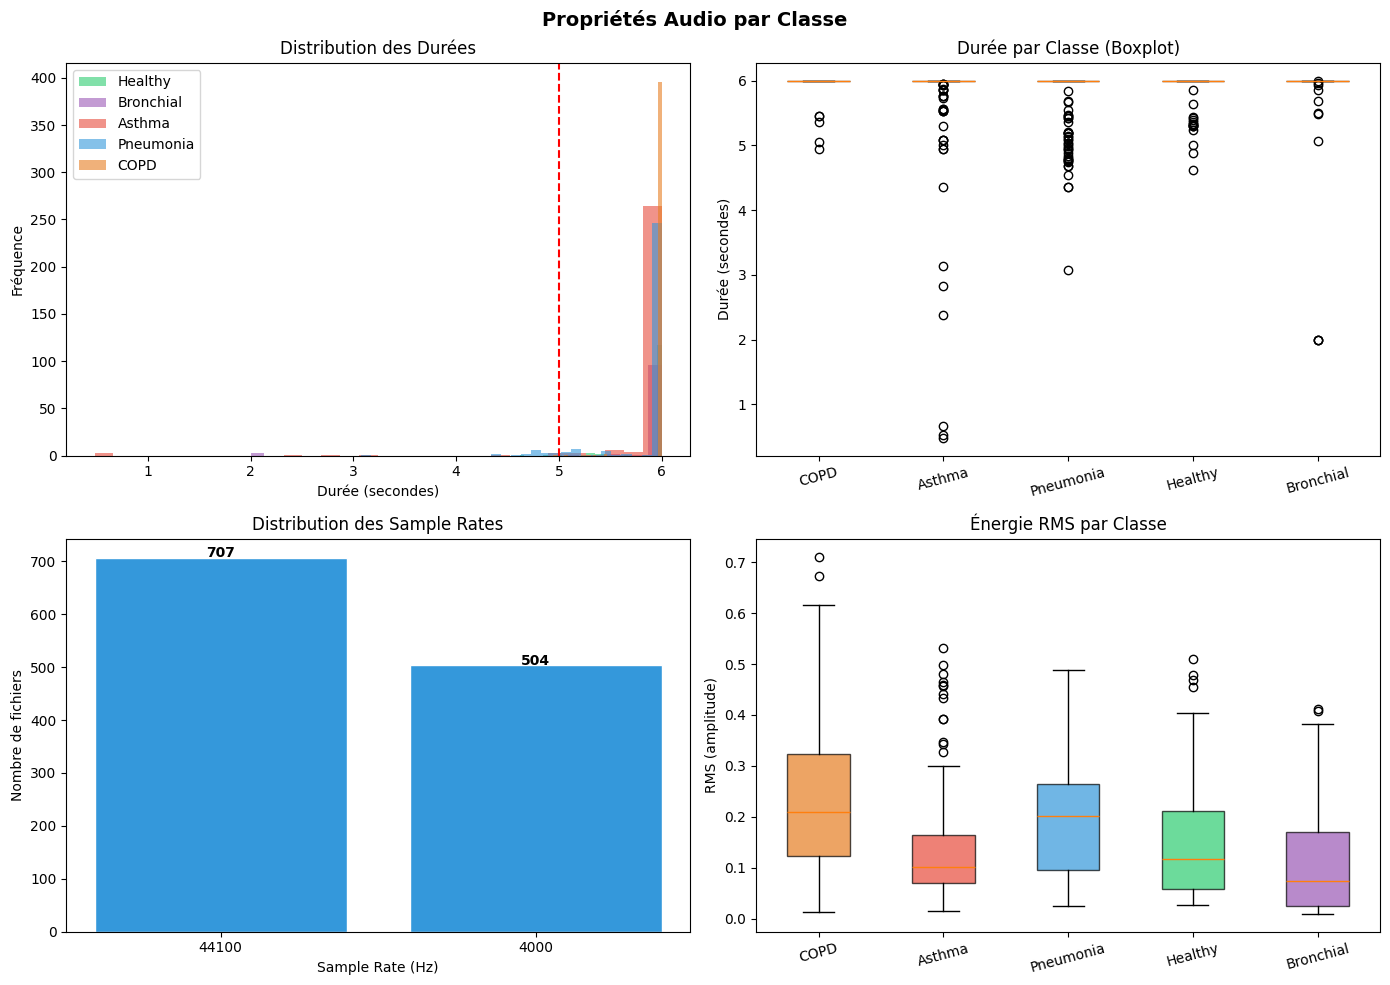

In [20]:
# ============================================================
# 5. ANALYSE DES PROPRIÉTÉS AUDIO
# ============================================================

print("\n" + "=" * 60)
print("ÉTAPE 5 : Analyse des propriétés audio")
print("=" * 60)

# Stats descriptives globales
print("\n- Statistiques globales :")
print(df_clean[['sample_rate', 'duration_s', 'amplitude_max', 'rms']].describe().round(3))

# Stats par classe
print("\n- Durée moyenne par classe (secondes) :")
print(df_clean.groupby('label')['duration_s'].agg(['mean','min','max','std']).round(2))

print("\n- Sample rates présents :")
print(df_clean['sample_rate'].value_counts())

# ---------- VISUALISATION ----------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Propriétés Audio par Classe", fontsize=14, fontweight='bold')

# Distribution des durées
for label in df_clean['label'].unique():
    subset = df_clean[df_clean['label'] == label]['duration_s']
    axes[0, 0].hist(subset, bins=30, alpha=0.6,
                    color=CLASS_COLORS.get(label, '#95A5A6'), label=label)
axes[0, 0].set_title("Distribution des Durées")
axes[0, 0].set_xlabel("Durée (secondes)")
axes[0, 0].set_ylabel("Fréquence")
axes[0, 0].legend()
axes[0, 0].axvline(x=5, color='red', linestyle='--', label='Cible: 5s')

# Boxplot durées par classe
data_by_class = [df_clean[df_clean['label'] == c]['duration_s'].dropna().values
                 for c in class_counts.index]
bp = axes[0, 1].boxplot(data_by_class, labels=class_counts.index, patch_artist=True)
for patch, color in zip(bp['boxes'], [CLASS_COLORS.get(c, '#95A5A6') for c in class_counts.index]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0, 1].set_title("Durée par Classe (Boxplot)")
axes[0, 1].set_ylabel("Durée (secondes)")
axes[0, 1].tick_params(axis='x', rotation=15)

# Distribution des sample rates
sr_counts = df_clean['sample_rate'].value_counts()
axes[1, 0].bar(sr_counts.index.astype(str), sr_counts.values, color='#3498DB', edgecolor='white')
axes[1, 0].set_title("Distribution des Sample Rates")
axes[1, 0].set_xlabel("Sample Rate (Hz)")
axes[1, 0].set_ylabel("Nombre de fichiers")
for i, (val) in enumerate(sr_counts.values):
    axes[1, 0].text(i, val + 0.5, str(val), ha='center', fontweight='bold')

# RMS (énergie) par classe
rms_by_class = [df_clean[df_clean['label'] == c]['rms'].dropna().values
                for c in class_counts.index]
bp2 = axes[1, 1].boxplot(rms_by_class, labels=class_counts.index, patch_artist=True)
for patch, color in zip(bp2['boxes'], [CLASS_COLORS.get(c, '#95A5A6') for c in class_counts.index]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].set_title("Énergie RMS par Classe")
axes[1, 1].set_ylabel("RMS (amplitude)")
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("proprietes_audio.png", dpi=150, bbox_inches='tight')
plt.show()



ÉTAPE 6 : Visualisation comparative des sons respiratoires


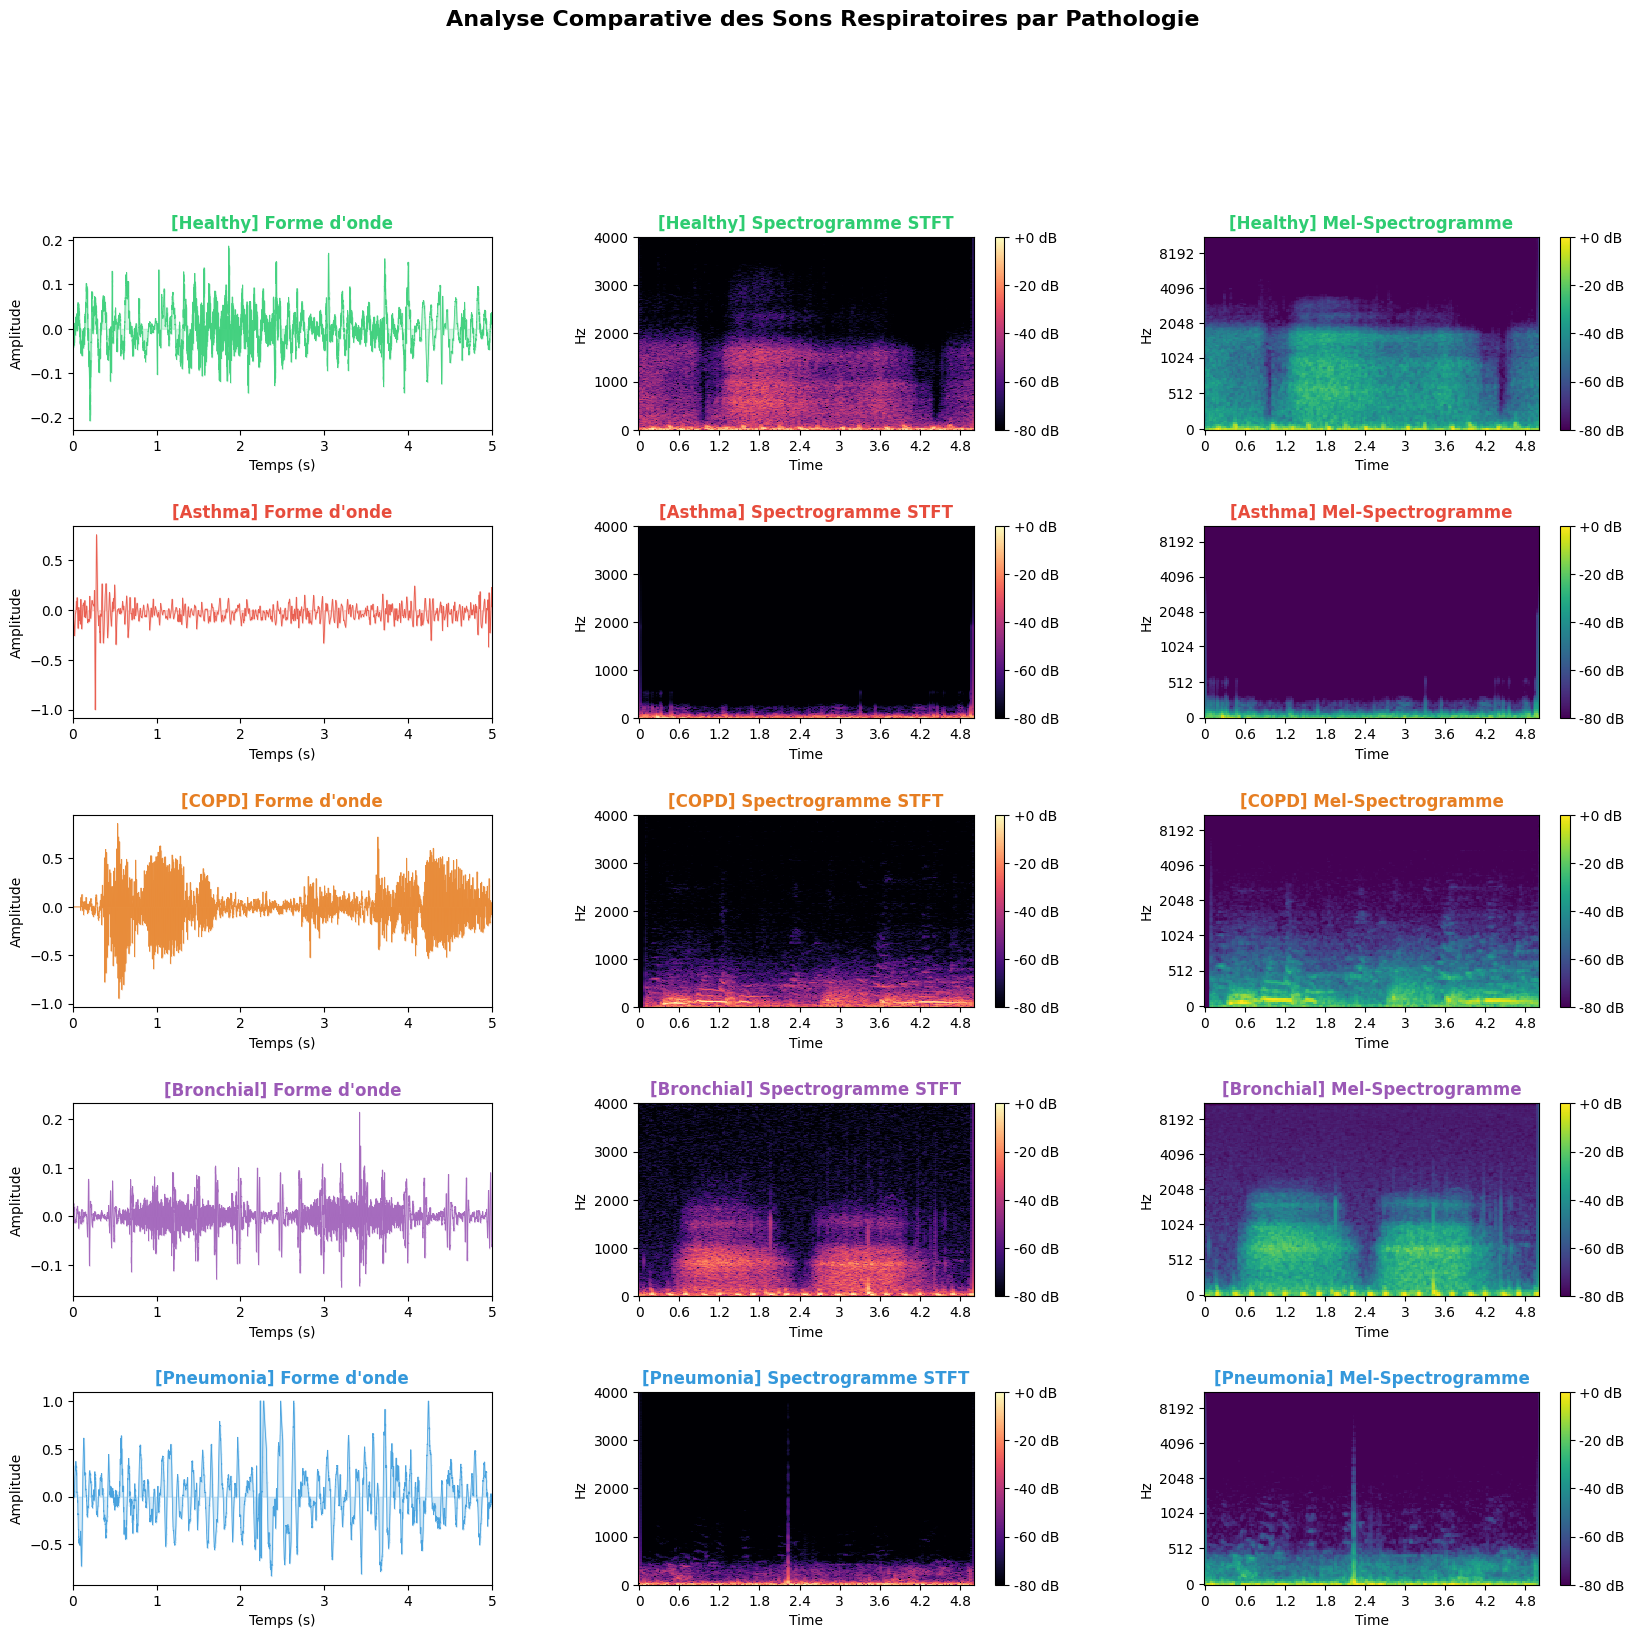

- Graphique sauvegardé : waveforms_spectrograms.png


In [21]:
# ============================================================
# 6. VISUALISATION DES FORMES D'ONDE & SPECTROGRAMMES
# ============================================================

print("\n" + "=" * 60)
print("ÉTAPE 6 : Visualisation comparative des sons respiratoires")
print("=" * 60)

TARGET_SR   = 22050
TARGET_DUR  = 5      # secondes
TARGET_SAMP = TARGET_SR * TARGET_DUR

def load_and_pad(filepath, sr=TARGET_SR, duration=TARGET_DUR):
    """Charge, resamplé, padde ou coupe à la durée cible."""
    y, _ = librosa.load(filepath, sr=sr, duration=duration)
    n_target = sr * duration
    if len(y) < n_target:
        y = np.pad(y, (0, n_target - len(y)))
    else:
        y = y[:n_target]
    return y

# Sélectionner 1 exemple par classe
samples = {}
for label in ['Healthy', 'Asthma', 'COPD', 'Bronchial', 'Pneumonia']:
    subset = df_clean[df_clean['label'] == label]
    if len(subset) > 0:
        row = subset.iloc[0]
        y   = load_and_pad(row['filepath'])
        samples[label] = y

# ---------- FIGURE PRINCIPALE : Waveform + Spectrogram + Mel ----------
n_classes = len(samples)
fig = plt.figure(figsize=(20, n_classes * 3.5))
fig.suptitle("Analyse Comparative des Sons Respiratoires par Pathologie",
             fontsize=16, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(n_classes, 3, figure=fig, hspace=0.5, wspace=0.35)

for i, (label, y) in enumerate(samples.items()):
    color = CLASS_COLORS.get(label, '#95A5A6')

    # --- Waveform ---
    ax1 = fig.add_subplot(gs[i, 0])
    times = np.linspace(0, TARGET_DUR, len(y))
    ax1.plot(times, y, color=color, linewidth=0.6, alpha=0.85)
    ax1.fill_between(times, y, alpha=0.2, color=color)
    ax1.set_title(f"[{label}] Forme d'onde", fontweight='bold', color=color)
    ax1.set_xlabel("Temps (s)")
    ax1.set_ylabel("Amplitude")
    ax1.set_xlim(0, TARGET_DUR)

    # --- Spectrogramme STFT ---
    ax2 = fig.add_subplot(gs[i, 1])
    D  = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img2 = librosa.display.specshow(D, sr=TARGET_SR, x_axis='time',
                                    y_axis='hz', ax=ax2, cmap='magma')
    ax2.set_title(f"[{label}] Spectrogramme STFT", fontweight='bold', color=color)
    ax2.set_ylim(0, 4000)  # Fréquences pulmonaires pertinentes
    fig.colorbar(img2, ax=ax2, format='%+2.0f dB')

    # --- Mel-Spectrogramme ---
    ax3 = fig.add_subplot(gs[i, 2])
    mel = librosa.feature.melspectrogram(y=y, sr=TARGET_SR,
                                          n_mels=128, n_fft=2048, hop_length=512)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img3 = librosa.display.specshow(mel_db, sr=TARGET_SR, x_axis='time',
                                     y_axis='mel', ax=ax3, cmap='viridis')
    ax3.set_title(f"[{label}] Mel-Spectrogramme", fontweight='bold', color=color)
    fig.colorbar(img3, ax=ax3, format='%+2.0f dB')

plt.savefig("waveforms_spectrograms.png", dpi=150, bbox_inches='tight')
plt.show()
print("- Graphique sauvegardé : waveforms_spectrograms.png")


In [22]:
# ============================================================
# 7. EXTRACTION DES FEATURES ACOUSTIQUES
# ============================================================

print("\n" + "=" * 60)
print("ÉTAPE 7 : Extraction et comparaison des features acoustiques")
print("=" * 60)

def extract_features(y, sr=TARGET_SR):
    """Extrait un vecteur de features acoustiques d'un signal audio."""
    features = {}

    # MFCC (20 coefficients → mean & std)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    for i in range(20):
        features[f'mfcc_{i+1}_mean'] = float(np.mean(mfcc[i]))
        features[f'mfcc_{i+1}_std']  = float(np.std(mfcc[i]))

    # Spectral Centroid
    sc = librosa.feature.spectral_centroid(y=y, sr=sr)
    features['spectral_centroid_mean'] = float(np.mean(sc))
    features['spectral_centroid_std']  = float(np.std(sc))

    # Spectral Bandwidth
    sb = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features['spectral_bandwidth_mean'] = float(np.mean(sb))
    features['spectral_bandwidth_std']  = float(np.std(sb))

    # Spectral Rolloff
    sr_feat = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features['spectral_rolloff_mean'] = float(np.mean(sr_feat))

    # Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y)
    features['zcr_mean'] = float(np.mean(zcr))
    features['zcr_std']  = float(np.std(zcr))

    # Chroma
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    features['chroma_mean'] = float(np.mean(chroma))
    features['chroma_std']  = float(np.std(chroma))

    # RMS Energy
    rms = librosa.feature.rms(y=y)
    features['rms_mean'] = float(np.mean(rms))
    features['rms_std']  = float(np.std(rms))

    # Tonnetz (relations tonales)
    y_harm = librosa.effects.harmonic(y)
    tonnetz = librosa.feature.tonnetz(y=y_harm, sr=sr)
    features['tonnetz_mean'] = float(np.mean(tonnetz))

    return features

# Extraire les features sur tout le dataset
print("- Extraction des features acoustiques (peut prendre ~3 min)...")
feat_list = []
for i, row in df_clean.iterrows():
    try:
        y = load_and_pad(row['filepath'])
        feats = extract_features(y)
        feats['label'] = row['label']
        feat_list.append(feats)
    except Exception as e:
        print(f"  ⚠️  Erreur sur {row['filename']} : {e}")
    if (i + 1) % 100 == 0:
        print(f"  ⏳ {len(feat_list)} features extraites...")

feat_df = pd.DataFrame(feat_list)
print(f"- Features extraites pour {len(feat_df)} fichiers")
print(f"- Dimensions : {feat_df.shape}")
print(feat_df[['label','spectral_centroid_mean','zcr_mean','rms_mean']].groupby('label').mean().round(4))



ÉTAPE 7 : Extraction et comparaison des features acoustiques
- Extraction des features acoustiques (peut prendre ~3 min)...
  ⏳ 100 features extraites...
  ⏳ 200 features extraites...
  ⏳ 300 features extraites...
  ⏳ 400 features extraites...
  ⏳ 500 features extraites...
  ⏳ 600 features extraites...
  ⏳ 700 features extraites...
  ⏳ 800 features extraites...
  ⏳ 900 features extraites...
  ⏳ 1000 features extraites...
  ⏳ 1100 features extraites...
  ⏳ 1200 features extraites...
- Features extraites pour 1211 fichiers
- Dimensions : (1211, 53)
           spectral_centroid_mean  zcr_mean  rms_mean
label                                                
Asthma                    75.3711    0.0029    0.1158
Bronchial                374.1838    0.0089    0.1031
COPD                     266.8352    0.0048    0.2127
Healthy                  275.4136    0.0034    0.1414
Pneumonia                167.1259    0.0024    0.1742



ÉTAPE 8 : Visualisation des features discriminantes


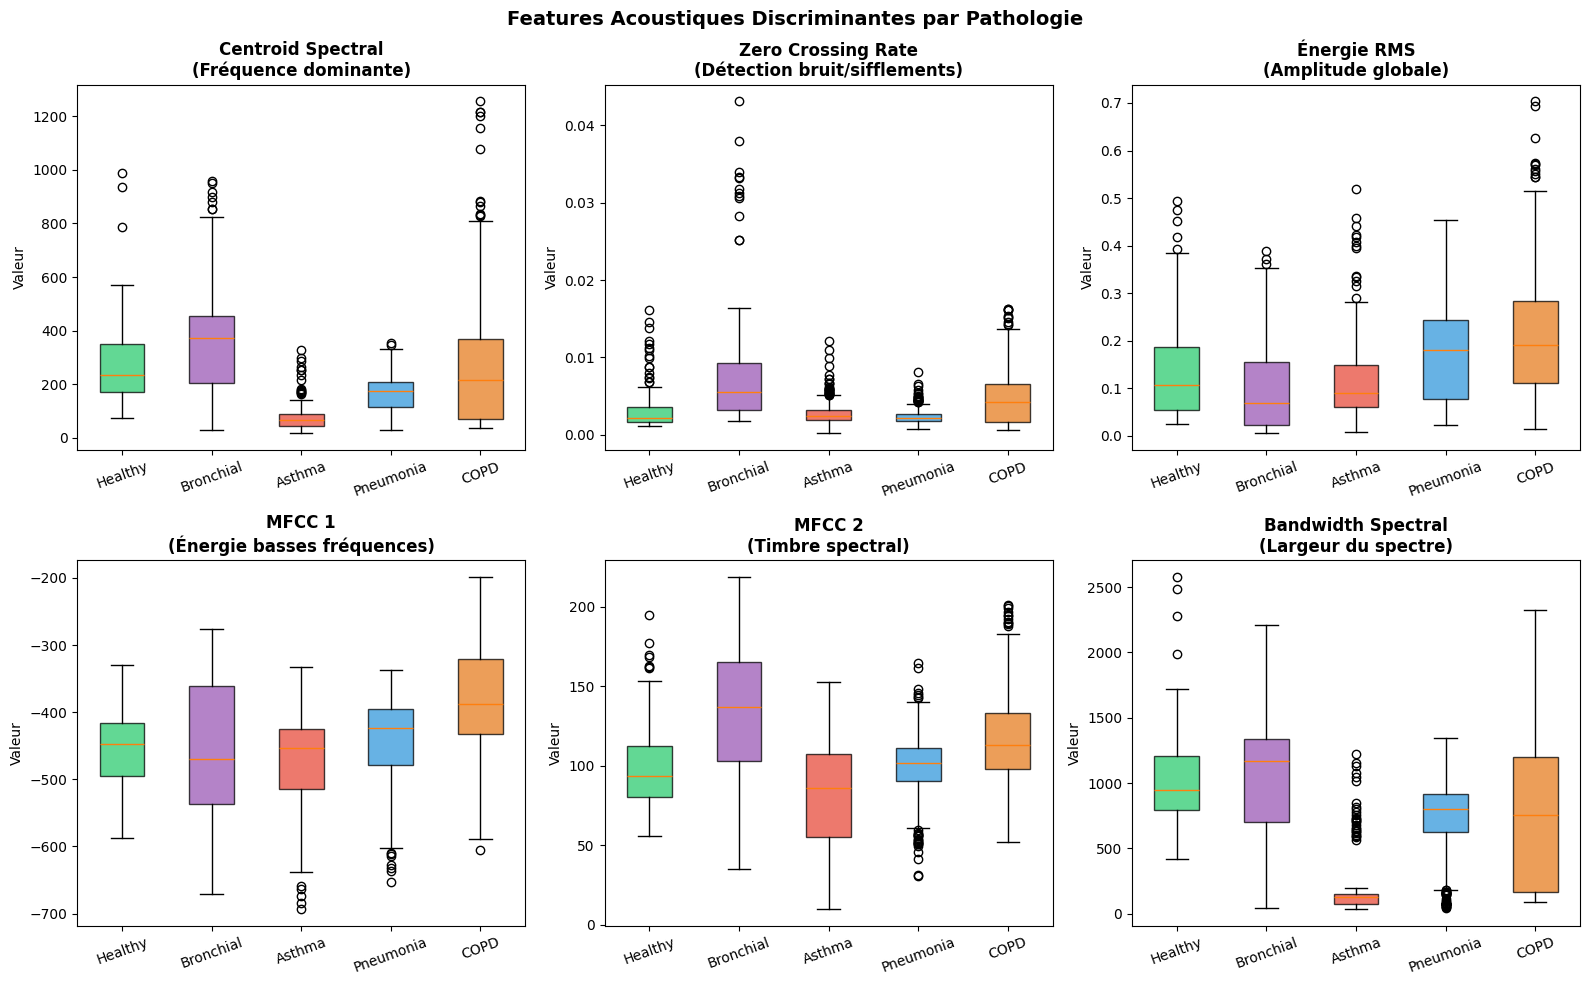

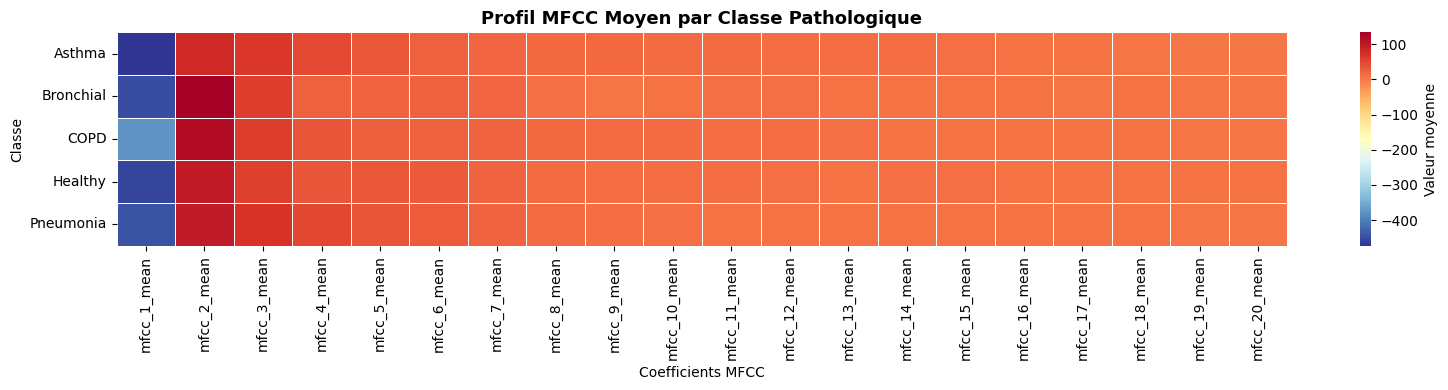

- Heatmap MFCC sauvegardée


In [23]:
# ============================================================
# 8. VISUALISATION DES FEATURES DISCRIMINANTES
# ============================================================

print("\n" + "=" * 60)
print("ÉTAPE 8 : Visualisation des features discriminantes")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Features Acoustiques Discriminantes par Pathologie", fontsize=14, fontweight='bold')

key_features = [
    ('spectral_centroid_mean', 'Centroid Spectral\n(Fréquence dominante)'),
    ('zcr_mean',               'Zero Crossing Rate\n(Détection bruit/sifflements)'),
    ('rms_mean',               'Énergie RMS\n(Amplitude globale)'),
    ('mfcc_1_mean',            'MFCC 1\n(Énergie basses fréquences)'),
    ('mfcc_2_mean',            'MFCC 2\n(Timbre spectral)'),
    ('spectral_bandwidth_mean','Bandwidth Spectral\n(Largeur du spectre)'),
]

classes = feat_df['label'].unique()
for ax, (feat, title) in zip(axes.flat, key_features):
    data = [feat_df[feat_df['label'] == c][feat].dropna().values for c in classes]
    bp   = ax.boxplot(data, labels=classes, patch_artist=True)
    for patch, cls in zip(bp['boxes'], classes):
        patch.set_facecolor(CLASS_COLORS.get(cls, '#95A5A6'))
        patch.set_alpha(0.75)
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    ax.set_ylabel("Valeur")

plt.tight_layout()
plt.savefig("features_discriminantes.png", dpi=150, bbox_inches='tight')
plt.show()

# Heatmap de corrélation des MFCC
mfcc_cols = [c for c in feat_df.columns if c.startswith('mfcc') and 'mean' in c]
mfcc_by_class = feat_df.groupby('label')[mfcc_cols].mean()

plt.figure(figsize=(16, 4))
sns.heatmap(mfcc_by_class, annot=False, cmap='RdYlBu_r',
            cbar_kws={'label': 'Valeur moyenne'}, linewidths=0.5)
plt.title("Profil MFCC Moyen par Classe Pathologique", fontsize=13, fontweight='bold')
plt.xlabel("Coefficients MFCC")
plt.ylabel("Classe")
plt.tight_layout()
plt.savefig("heatmap_mfcc.png", dpi=150, bbox_inches='tight')
plt.show()
print("- Heatmap MFCC sauvegardée")


In [26]:
# ============================================================
# 9. RAPPORT FINAL D'EXPLORATION
# ============================================================

print("\n" + "=" * 60)
print("RAPPORT FINAL D'EXPLORATION")
print("=" * 60)

print(f"""
- DATASET
   • Total fichiers valides  : {len(df_clean)}
   • Nombre de classes       : {df_clean['label'].nunique()}
   • Classes                 : {sorted(df_clean['label'].unique())}

-  DÉSÉQUILIBRE DE CLASSES
   • Classe majoritaire      : {majority} ({class_counts[majority]} samples | {class_pct[majority]:.1f}%)
   • Classe minoritaire      : {minority} ({class_counts[minority]} samples | {class_pct[minority]:.1f}%)
   • Ratio de déséquilibre   : {imb_ratio:.1f}x
   → Action requise : class_weight='balanced' + data augmentation

- PROPRIÉTÉS AUDIO
   • Durée moyenne           : {df_clean['duration_s'].mean():.2f}s
   • Durée min - max         : {df_clean['duration_s'].min():.2f}s - {df_clean['duration_s'].max():.2f}s
   • Sample rates            : {sorted(df_clean['sample_rate'].dropna().unique().astype(int).tolist())} Hz
   → Action requise : resampling à 22 050 Hz, padding/crop à 5s

- RECOMMANDATIONS PRÉTRAITEMENT
   1. Resampling  : 22 050 Hz (standard librosa)
   2. Durée fixe  : 5 secondes (pad silence - crop)
   3. Filtre      : passe-bande 100–2000 Hz (sons pulmonaires)
   4. Normalisation : amplitude peak → [-1, 1]
   5. Mel-spectrogramme : n_mels=128, n_fft=2048, hop_length=512
   6. Gestion déséquilibre :
      - Augmentation audio sur classes minoritaires
      - class_weight dans la loss function
      - Metric principale : Macro F1-Score (pas accuracy)
""")

# Sauvegarde du catalogue enrichi
df_clean.to_csv("dataset_catalogue.csv", index=False)
feat_df.to_csv("features_acoustiques.csv", index=False)
print("- Fichiers sauvegardés :")
print("   → dataset_catalogue.csv   (métadonnées de tous les fichiers)")
print("   → features_acoustiques.csv (features extraites par fichier)")



RAPPORT FINAL D'EXPLORATION

- DATASET
   • Total fichiers valides  : 1211
   • Nombre de classes       : 5
   • Classes                 : ['Asthma', 'Bronchial', 'COPD', 'Healthy', 'Pneumonia']

-  DÉSÉQUILIBRE DE CLASSES
   • Classe majoritaire      : COPD (401 samples | 33.1%)
   • Classe minoritaire      : Bronchial (104 samples | 8.6%)
   • Ratio de déséquilibre   : 3.9x
   → Action requise : class_weight='balanced' + data augmentation

- PROPRIÉTÉS AUDIO
   • Durée moyenne           : 5.91s
   • Durée min - max         : 0.48s - 6.00s
   • Sample rates            : [4000, 44100] Hz
   → Action requise : resampling à 22 050 Hz, padding/crop à 5s

- RECOMMANDATIONS PRÉTRAITEMENT
   1. Resampling  : 22 050 Hz (standard librosa)
   2. Durée fixe  : 5 secondes (pad silence - crop)
   3. Filtre      : passe-bande 100–2000 Hz (sons pulmonaires)
   4. Normalisation : amplitude peak → [-1, 1]
   5. Mel-spectrogramme : n_mels=128, n_fft=2048, hop_length=512
   6. Gestion déséquilibre :
  